<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/LongTermInvesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install --upgrade yfinance


In [26]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
from datetime import datetime
import time
import seaborn as sns
import matplotlib.pyplot as plt
print("Libraries Installed!")

0.2.66
Libraries Installed!


In [27]:

def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix




[*********************100%***********************]  33 of 33 completed


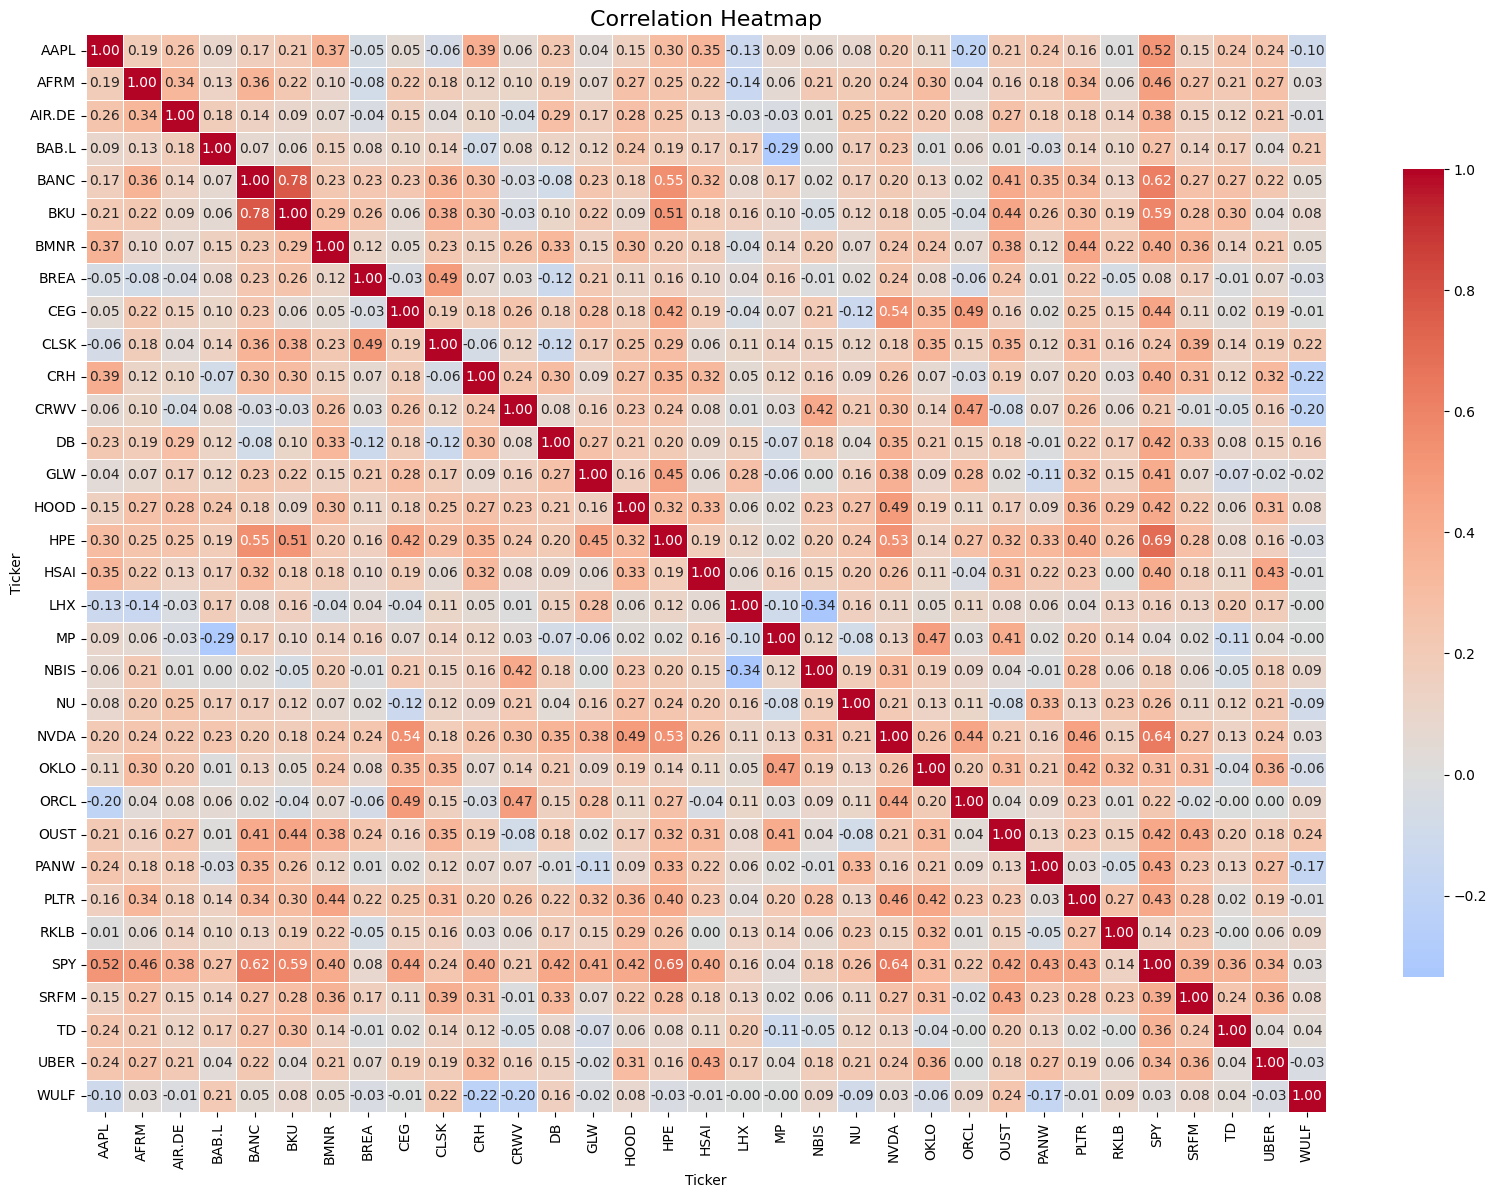

In [28]:
df_raw = pd.read_csv('longterm.csv')

# Example usage
tickers = df_raw['Asset'].to_list()
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(20, 14))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [29]:

#print("Final uncorrelated picks:", final_selection)
#print("\nCorrelation matrix:\n", corr_matrix)

# Keep only rows where Asset is in filtered
filtered_list = df_raw[df_raw["Asset"].isin(final_selection)]

buy_list = filtered_list.copy()
buy_list.head()

,Asset,Momentum,score
0,WULF,Strong,4.66
1,NBIS,Strong,4.02
2,OKLO,Strong,2.70
3,CLSK,Strong,2.06
4,BMNR,Weak,1.53


In [30]:
def money_flow_signals(df, period=10):
    """
    Calculate Money Flow Index (MFI) and generate signals:
    - Positive money flow (TP > TP_prev)
    - Divergence (Price vs MFI mismatch)

    Parameters:
        df (pd.DataFrame): DataFrame with columns ["High", "Low", "Close", "Volume"]
        period (int): Lookback period for MFI (default=10)

    Returns:
        pd.DataFrame with added columns: ["TypicalPrice", "MFI", "PositiveFlow", "Divergence"]
    """

    df = df.copy()

    # Step 1: Typical Price
    df["TypicalPrice"] = (df["High"] + df["Low"] + df["Close"]) / 3

    # Step 2: Raw Money Flow
    df["RawMoneyFlow"] = df["TypicalPrice"] * df["Volume"]

    # Step 3: Positive & Negative Flow
    df["PositiveFlow"] = np.where(df["TypicalPrice"] > df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)
    df["NegativeFlow"] = np.where(df["TypicalPrice"] < df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)

    # Step 4: Money Flow Ratio & MFI
    pos_flow = df["PositiveFlow"].rolling(period).sum()
    neg_flow = df["NegativeFlow"].rolling(period).sum()
    money_flow_ratio = pos_flow / neg_flow.replace(0, np.nan)
    df["MFI"] = 100 - (100 / (1 + money_flow_ratio))

    # Step 5: Positive Money Flow Signal
    df["PositiveFlowSignal"] = df["TypicalPrice"] > df["TypicalPrice"].shift(1)

    # Step 6: Divergence Detection
    df["PriceHigh"] = df["Close"].rolling(period).max()
    df["PriceLow"] = df["Close"].rolling(period).min()
    df["MFIHigh"] = df["MFI"].rolling(period).max()
    df["MFILow"] = df["MFI"].rolling(period).min()

    def divergence(row):
        if np.isnan(row["MFI"]):
            return None
        # Price makes higher high, but MFI does not
        if row["Close"] >= row["PriceHigh"] and row["MFI"] < row["MFIHigh"]:
            return "Bearish Divergence ⚠️"
        # Price makes lower low, but MFI does not
        elif row["Close"] <= row["PriceLow"] and row["MFI"] > row["MFILow"]:
            return "Bullish Divergence ✅"
        else:
            return "No Divergence"

    df["Divergence"] = df.apply(divergence, axis=1)
    df['Entry_signal']= (df["MFI"] > 50) & (df["Divergence"] == "No Divergence")
    curr = df.iloc[-1]

    return curr.Entry_signal

In [31]:
def check_entry_conditions(tickers):
    results = []
    for ticker in tickers:
      df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
      if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first leve
      mfi_signal = money_flow_signals(df)
      # Print results
      print(f"\nMoney flow indicator for {ticker} is:")
      print(mfi_signal)

      refined_entry_signal = mfi_signal


      if mfi_signal :
        entry_signal = "Entry"
      else:
        entry_signal = "Bearish"
      results.append([ticker, entry_signal])
    # Convert results to DataFrame
    df_results = pd.DataFrame(results, columns=["Asset", "Entry_Signal"])
    return df_results


In [32]:
final_etfs_to_check = buy_list['Asset'].to_list()
buy_lists = check_entry_conditions(final_etfs_to_check)
df = buy_lists[buy_lists['Entry_Signal'] =="Entry"]
df.reset_index(drop=True, inplace=True)
df

[*********************100%***********************]  1 of 1 completed



Money flow indicator for WULF is:
False


[*********************100%***********************]  1 of 1 completed



Money flow indicator for NBIS is:
True


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed



Money flow indicator for DB is:
True


[*********************100%***********************]  1 of 1 completed


Money flow indicator for NVDA is:
False


,Asset,Entry_Signal
0,NBIS,Entry
1,OKLO,Entry
2,CLSK,Entry
3,RKLB,Entry
4,GLW,Entry
5,CRWV,Entry
6,MP,Entry
7,OUST,Entry
8,SRFM,Entry
9,CRH,Entry


# Three months Relative Strength

In [33]:
tickers = df.Asset.to_list()
data = yf.download(tickers, start="2024-01-01", interval="1d",auto_adjust=True)["Close"]

# Compute returns
returns = data.pct_change()

# Lookback window (3 months ~ 63 trading days)
#window = 63

# Inspect dataframe
data.tail()

[*********************100%***********************]  17 of 17 completed


Ticker,AFRM,BANC,CLSK,CRH,CRWV,DB,GLW,HPE,MP,NBIS,OKLO,ORCL,OUST,PANW,PLTR,RKLB,SRFM
Date,,,,,,,,,,,,,,,,,
2025-10-08,75.250000,17.709999,18.980000,117.849998,139.979996,35.330002,87.070000,26.080000,70.589996,122.000000,134.770004,288.130005,30.650000,217.789993,183.559998,65.309998,5.45
2025-10-09,77.459999,17.600000,20.090000,117.610001,143.080002,35.240002,87.190002,26.250000,72.290001,132.639999,138.130005,296.959991,30.850000,215.169998,185.470001,66.419998,5.39
2025-10-10,71.139999,16.480000,19.280001,116.029999,138.429993,34.560001,82.980003,24.400000,78.339996,129.580002,147.160004,292.959991,27.860001,208.550003,175.440002,64.260002,5.00
2025-10-13,73.180000,16.980000,20.040001,117.540001,141.619995,35.299999,85.500000,24.799999,95.059998,135.460007,171.009995,308.010010,31.070000,213.279999,177.210007,65.419998,5.13
2025-10-14,72.919998,17.490000,21.980000,120.120003,134.059998,35.279999,84.610001,25.000000,98.650002,128.149994,174.139999,299.000000,36.160000,207.559998,179.740005,68.029999,5.09


In [34]:

def compute_relative_strength(prices, method="raw",window=63):
    # Fill missing values before calling pct_change
    prices_filled = prices.ffill()  # forward-fill any missing data
    roc = prices_filled.pct_change(window) # 3-month return

    if method == "raw":
        rs = roc
    elif method == "vol_adj":
        vol = returns.rolling(window).std() * np.sqrt(window)
        rs = roc / vol
    else:
        raise ValueError("Method must be 'raw' or 'vol_adj'")

    return rs


    # Compute signals
rs_raw = compute_relative_strength(data, method="raw",window=63)
rs_vol = compute_relative_strength(data, method="vol_adj",window=63)
rs_avg = 0.5 * rs_raw + 0.5 * rs_vol

# Resample monthly (take last available signal each month)
#rs_raw_m = rs_raw.resample("ME").last()
#rs_raw_m = rs_vol.resample("ME").last()
rs_raw_m = rs_avg.resample("ME").last()

#print("Relative strengths are :",rs_raw_m )
#rs_raw_m.tail(10)
# Select the last row
last_row = rs_raw_m.tail(1).T
# Sort columns in last row (descending)
sorted_filtered = last_row[last_row.iloc[:, 0] >= 0.].sort_values(by=rs_raw_m.index[-1], ascending=False)

sorted_filtered

/tmp/ipython-input-976473186.py:4: FutureWarning: The 'fill_method' keyword being not None and the 'limit' keyword in DataFrame.pct_change are deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  roc = prices_filled.pct_change(window,fill_method='ffill') # 3-month return


Date,2025-10-31
Ticker,
OKLO,2.435219
GLW,2.117851
NBIS,1.877527
CLSK,1.394965
MP,1.300580
CRH,1.132860
HPE,0.901542
BANC,0.825097
RKLB,0.790641


# 1 Month Relative Strength for confirmation

In [35]:
rs_3m_list =sorted_filtered.index
tickers= rs_3m_list.tolist()

data2 = yf.download(tickers, start="2024-01-01", interval="1d",auto_adjust=True)["Close"]

# Compute returns
returns = data2.pct_change()

# Lookback window (1 months ~ 30 trading days)
window = 30


def compute_relative_strength(prices, method="raw",window=30):
    # Fill missing values before calling pct_change
    prices_filled = prices.ffill()  # forward-fill any missing data
    roc = prices_filled.pct_change(window) # 1-month return

    if method == "raw":
        rs = roc
    elif method == "vol_adj":
        vol = returns.rolling(window).std() * np.sqrt(window)
        rs = roc / vol
    else:
        raise ValueError("Method must be 'raw' or 'vol_adj'")

    return rs


    # Compute signals
rs_raw = compute_relative_strength(data2, method="raw",window=30)
rs_vol = compute_relative_strength(data2, method="vol_adj",window=30)
rs_avg = 0.5 * rs_raw + 0.5 * rs_vol

# Resample monthly (take last available signal each month)
#rs_raw_m = rs_raw.resample("ME").last()
#rs_raw_m = rs_vol.resample("ME").last()
rs_raw_m = rs_avg.resample("ME").last()

#print("Relative strengths are :",rs_raw_m )
#rs_raw_m.tail(10)
# Select the last row
last_row = rs_raw_m.tail(1).T
# Sort columns in last row (descending)
refined_filtered = last_row[last_row.iloc[:, 0] >= 0.].sort_values(by=rs_raw_m.index[-1], ascending=False)

refined_filtered

[*********************100%***********************]  15 of 15 completed


Date,2025-10-31
Ticker,
CLSK,2.811330
OKLO,2.264389
NBIS,1.370623
GLW,1.322337
MP,1.011399
RKLB,0.829019
PANW,0.581796
OUST,0.577933
ORCL,0.576507
